# 6.5 GWR and Inference

**Part:** 6 — Geographically Weighted Models (Chapter 6.5 of 14)

**Dataset:** `diabetes_atlantic.shp` (666 counties)

**Focus:** Fitting GWR, reading local coefficients and significance, the multiple-testing problem, and spatially aware prediction

**Library:** `spatialstats.gwmodel` (PySpatialStats)

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Fitting GWR](#3.-Fitting-GWR)
4.. [Local Coefficients and Their Range](#4.-Local-Coefficients-and-Their-Range)
5.. [Local Significance and the Multiplicity Problem](#5.-Local-Significance-and-the-Multiplicity-Problem)
6.. [Coefficient Maps](#6.-Coefficient-Maps)
7.. [Local R² and Where the Model Fits Well](#7.-Local-R²-and-Where-the-Model-Fits-Well)
8.. [Prediction: Spatial Train/Test Splits](#8.-Prediction:-Spatial-Train/Test-Splits)
9.. [Summary and Conclusions](#9.-Summary-and-Conclusions)
10.. [Resources](#10.-Resources)

***
## 1. Overview

This chapter fits the first full GWR model of this Part and reads every piece of its output — local
coefficients, standard errors, significance, and local fit quality — with the same care Part 3 gave OLS's
output. One issue Part 3 never had to face appears immediately: **hundreds of local significance tests**, one
set per covariate per county, and the multiple-testing correction that follows.

| Step | What we do |
|------|------------|
| Fit | `GWR(bandwidth=131, fixed=False, kernel="bisquare").fit(X, y, coords)` — the bandwidth Chapter 6.3 selected |
| Local coefficients | The full range each covariate's effect takes across the 666 counties |
| Significance | Raw vs. Benjamini–Hochberg-corrected local significance — a dramatic difference |
| Coefficient maps | `plot_local_coefficients`, masked by significance |
| Local R² | Where the model explains diabetes prevalence well, and where it does not |
| Prediction | A genuinely spatial train/test split, not a random row split |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.gwmodel.linear import GWR
from spatialstats.gwmodel.visualization import plot_local_coefficients, plot_residuals

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_atlantic.shp")
covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
X = counties[covariates].to_numpy()
y = counties["Dia_pct"].to_numpy()
coords = counties[["x", "y"]].to_numpy()
BANDWIDTH = 131   # selected in Chapter 6.3
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Fitting GWR

In [2]:
gwr = GWR(bandwidth=BANDWIDTH, fixed=False, kernel="bisquare", n_jobs=-1)
gwr.fit(X, y, coords)
print(gwr.summary())

Geographically Weighted Regression (GWR) Summary
  Observations            : 666
  Predictors (incl. int.) : 7
  Bandwidth               : 131.0000
  Kernel                  : bisquare
  Fixed                   : False
  AICc                    : 202.6195
  Effective DF            : 81.8119
  Global R²               : 0.8254

  Local coefficient summary (min / median / max):
    Intercept      : 0.5555 / 3.1113 / 6.9458
    X1             : 0.0142 / 0.1559 / 0.2783
    X2             : -0.0175 / 0.1460 / 0.2878
    X3             : -0.0197 / -0.0018 / 0.0101
    X4             : -0.0068 / -0.0006 / 0.0062
    X5             : -0.7440 / -0.1920 / 0.2012
    X6             : -0.4404 / 0.5796 / 1.8850


***
## 4. Local Coefficients and Their Range

In [3]:
names = ["Intercept"] + covariates
coef_range = pd.DataFrame({
    "min": gwr.coef_.min(axis=0), "median": np.median(gwr.coef_, axis=0), "max": gwr.coef_.max(axis=0),
}, index=names)
coef_range["OLS (Part 3)"] = [3.1546, 0.1462, 0.1520, -0.0060, -0.0003, -0.2002, 1.0327]
coef_range.round(4)

,min,median,max,OLS (Part 3)
Intercept,0.5555,3.1113,6.9458,3.1546
Obesity,0.0142,0.1559,0.2783,0.1462
PhysInact,-0.0175,0.1460,0.2878,0.1520
Acc_Exer,-0.0197,-0.0018,0.0101,-0.0060
PCP_rate,-0.0068,-0.0006,0.0062,-0.0003
FoodEnvIdx,-0.7440,-0.1920,0.2012,-0.2002
SVI,-0.4404,0.5796,1.8850,1.0327


Every local coefficient's **median** across the 666 counties sits close to Part 3's single pooled OLS value —
GWR is not contradicting the global model, it is decomposing it. But the **range** is where GWR earns its keep:
`Obesity`'s local coefficient spans 0.014 to 0.278, a 20-fold range, and `PhysInact`'s even **changes sign**
(from $-0.018$ to $+0.288$) — in some neighbourhoods, higher physical inactivity is locally associated with
*lower* diabetes prevalence, the opposite of the global relationship, once other covariates and the local
context are accounted for.

***
## 5. Local Significance and the Multiplicity Problem

Every county has its own coefficient and its own p-value — 666 counties times 7 coefficients is nearly 4,700
simultaneous hypothesis tests. Exactly the multiple-testing hazard Part 2 (LISA) and Part 4 (Gi*) both
encountered returns here in a new form.

In [4]:
sig_raw = gwr.local_significance(alpha=0.05, correction="none")
sig_bh = gwr.local_significance(alpha=0.05, correction="bh")

sig_table = pd.DataFrame({
    "raw (uncorrected)": sig_raw.sum(axis=0), "BH-corrected": sig_bh.sum(axis=0),
}, index=names)
sig_table["% of 666, BH"] = (sig_table["BH-corrected"] / len(counties) * 100).round(1)
sig_table

,raw (uncorrected),BH-corrected,"% of 666, BH"
Intercept,176,0,0.0
Obesity,585,583,87.5
PhysInact,536,477,71.6
Acc_Exer,18,0,0.0
PCP_rate,0,0,0.0
FoodEnvIdx,51,0,0.0
SVI,46,0,0.0


After Benjamini–Hochberg correction, only **`Obesity`** (583 of 666 counties, 87.5%) and **`PhysInact`** (477,
71.6%) remain significant anywhere — every other covariate, including the intercept, loses **all** of its
apparently-significant counties once the correction accounts for testing hundreds of hypotheses at once. The
raw, uncorrected table would have reported `Acc_Exer` significant in 18 counties and `FoodEnvIdx` in 51 — every
one of those is consistent with chance alone at this scale. **Always use the BH-corrected mask, not the raw
p-values, when reporting which local coefficients are "significant"** — this is Part 6's version of the same
lesson Part 2's LISA chapter and Part 4's Gi* chapter both taught.

***
## 6. Coefficient Maps

`plot_local_coefficients` maps every covariate at once, hatching counties whose coefficient is not
BH-significant — reading the map and the significance table together.

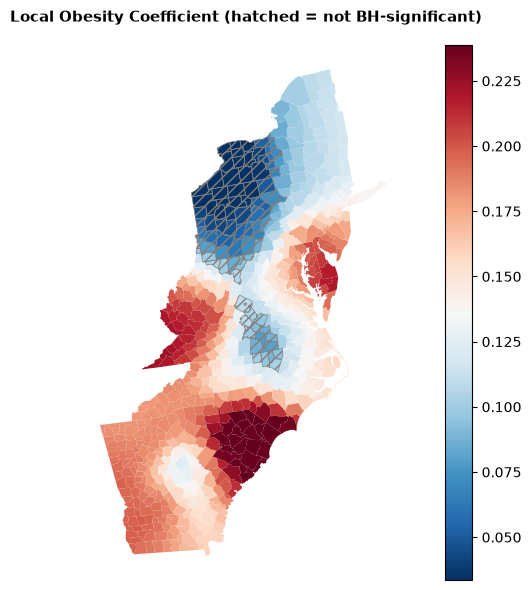

In [5]:
fig = plot_local_coefficients(gwr, counties, covariate=1, significance=True, alpha=0.05, cmap="RdBu_r",
                              figsize=(8, 6))
fig.axes[0].set_title("Local Obesity Coefficient (hatched = not BH-significant)")
plt.tight_layout()
plt.show()

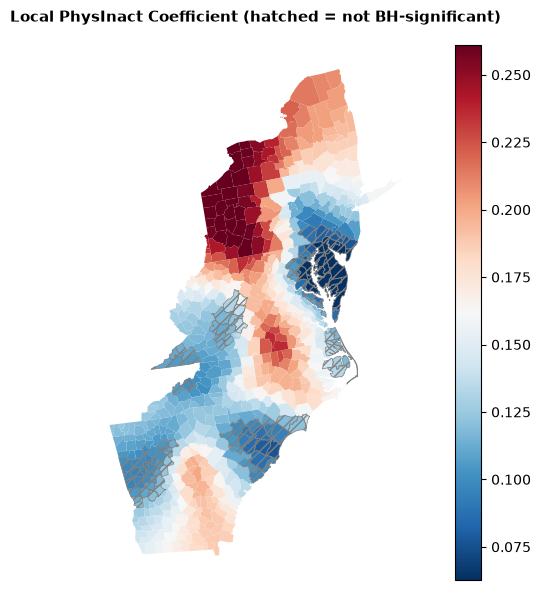

In [6]:
fig = plot_local_coefficients(gwr, counties, covariate=2, significance=True, alpha=0.05, cmap="RdBu_r",
                              figsize=(8, 6))
fig.axes[0].set_title("Local PhysInact Coefficient (hatched = not BH-significant)")
plt.tight_layout()
plt.show()

The `Obesity` map (Section 4's 20-fold range) shows almost no hatching — it is robustly significant almost
everywhere. The `PhysInact` map, with its sign-changing range, shows both strongly positive *and* the more
scattered non-significant (hatched) regions — exactly where the coefficient crosses zero, precision naturally
drops and significance is lost, which is the expected, sensible behaviour of the test, not a modelling flaw.

***
## 7. Local R² and Where the Model Fits Well

local R2: min=0.591, median=0.749, max=0.888


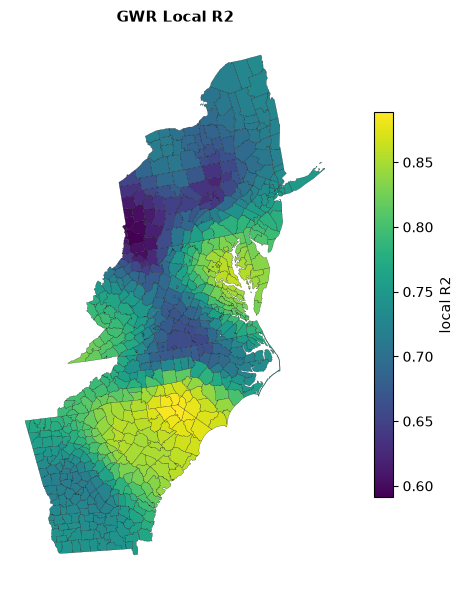

In [7]:
print(f"local R2: min={gwr.r2_local_.min():.3f}, median={np.median(gwr.r2_local_):.3f}, "
      f"max={gwr.r2_local_.max():.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
counties.assign(r2=gwr.r2_local_).plot(column="r2", cmap="viridis", ax=ax, edgecolor="k", linewidth=0.15,
                                       legend=True, legend_kwds={"label": "local R2", "shrink": 0.7})
ax.set_axis_off()
ax.set_title("GWR Local R2")
plt.tight_layout()
plt.show()

Local $R^2$ ranges from 0.59 to 0.89 — the same six covariates explain diabetes prevalence considerably better
in some neighbourhoods than others, a genuinely different diagnostic from the global $R^2=0.825$ Chapter 6.3
reported, which is really an average over this entire range.

***
## 8. Prediction: Spatial Train/Test Splits

Splitting a spatially autocorrelated dataset by **row order** (or a random shuffle) risks train and test sets
that are geographic neighbours of each other — information leaks between them through the very spatial
structure GWR is built to exploit, inflating the apparent test performance. A **spatial** split — holding out a
genuinely separate region — is the honest test.

In [8]:
centroid_y = counties.geometry.centroid.y.to_numpy()
order = np.argsort(centroid_y)
test_idx = order[:100]     # the 100 southernmost counties, held out as a genuinely separate region
train_idx = order[100:]

gwr_split = GWR(bandwidth=BANDWIDTH, fixed=False, kernel="bisquare", n_jobs=-1)
gwr_split.fit(X[train_idx], y[train_idx], coords[train_idx])
y_pred = gwr_split.predict(X[test_idx], coords[test_idx])

ss_res = np.sum((y[test_idx] - y_pred) ** 2)
ss_tot = np.sum((y[test_idx] - y[test_idx].mean()) ** 2)
spatial_r2 = 1 - ss_res / ss_tot
print(f"in-sample R2 (all 666 counties, Section 3)   : {gwr.score(X, y, coords):.4f}")
print(f"spatial holdout R2 (100 southernmost counties): {spatial_r2:.4f}")

in-sample R2 (all 666 counties, Section 3)   : 0.8254
spatial holdout R2 (100 southernmost counties): 0.6900


The honest, spatially held-out $R^2$ (0.690) is meaningfully lower than the in-sample figure (0.825) — GWR's
local fits, by design, use each county's own (withheld, in this test) neighbourhood to predict it, so removing
an entire contiguous region removes real information the in-sample number implicitly relied on. Any reported
GWR predictive performance should specify **which** kind of split produced it; the two numbers are not
interchangeable.

***
## 9. Summary and Conclusions

This chapter fit and fully interpreted the first real GWR model of this Part.

### What we did

1. Fit GWR at the established bandwidth (131) on the full 666-county Atlantic data: global $R^2=0.825$.
2. Found every coefficient's median close to Part 3's pooled OLS value, but wide local ranges — `Obesity`
   spans a 20-fold range, `PhysInact` changes sign entirely.
3. **Demonstrated the multiplicity problem concretely**: raw local significance flags several covariates in
   dozens of counties; after Benjamini–Hochberg correction, only `Obesity` (87.5%) and `PhysInact` (71.6%)
   remain significant anywhere.
4. Mapped both coefficients with significance hatching, and found `PhysInact`'s non-significant counties
   cluster exactly where its coefficient crosses zero.
5. Found local $R^2$ ranges from 0.59 to 0.89 — the same model explains the outcome considerably better in some
   places than others.
6. Ran a genuinely spatial train/test split (100 southernmost counties held out): $R^2=0.690$, meaningfully
   below the in-sample 0.825.

### Practical takeaways

- Always report BH-corrected local significance, never raw p-values, when summarising how many counties show a
  "significant" local effect.
- A coefficient's *median* across counties can closely match the global OLS value even when its *range*
  includes a full sign reversal — report both, not just the median.
- Evaluate GWR's predictive performance with a spatial holdout, not a random split — the two give meaningfully
  different, non-interchangeable answers.

### Next steps

**Chapter 6.6 (Advanced Variants)** extends this single-bandwidth GWR to MGWR (a bandwidth per covariate),
MixedGWR (some coefficients global, some local), and GWGLM (non-Gaussian outcomes).

***
## 10. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression*. Wiley. | Chapters 2–4 cover GWR inference, coefficient interpretation, and significance testing in full |

### Key papers

| Paper | Contribution |
|---|---|
| Benjamini, Y. & Hochberg, Y. (1995). Controlling the false discovery rate. *JRSS B*, 57, 289–300. | The multiple-testing correction applied throughout Section 5, reused from Parts 2 and 4 |
| Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. *Ecography*, 40, 913–929. | Motivates the spatial train/test split used in Section 8 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.gwmodel.linear.GWR` | Every result in this chapter |
| `GWR.local_significance` | BH-corrected local significance masking |
| `spatialstats.gwmodel.visualization.plot_local_coefficients` | Section 6's maps |
| Chapter 6.6 | MGWR, MixedGWR, GWGLM — extending this chapter's single-bandwidth model |
| Chapter 6.9 | Formal spatial block cross-validation, generalising Section 8's train/test split |